In [29]:
import pandas as pd
dataset=pd.read_csv("preplacement.csv")
df = dataset.iloc[:, 1:]
df.isnull().sum()

ssc_p       0
hsc_p       0
degree_p    0
etest_p     0
mba_p       0
salary      0
dtype: int64

In [30]:
dir(df)

['T',
 '_AXIS_LEN',
 '_AXIS_ORDERS',
 '_AXIS_REVERSED',
 '_AXIS_TO_AXIS_NUMBER',
 '_HANDLED_TYPES',
 '__abs__',
 '__add__',
 '__and__',
 '__annotations__',
 '__array__',
 '__array_priority__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__class__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__divmod__',
 '__doc__',
 '__eq__',
 '__finalize__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__imod__',
 '__imul__',
 '__init__',
 '__init_subclass__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__module__',
 '__mul__',
 '__ne__',
 '__neg__',
 '__new__',
 '__nonzero__',
 '__or__',
 '__pos__',
 '__pow__',
 '__radd__',
 '__rand__',
 '__rdivmod__',
 '__reduce__',
 '__reduce_ex

In [31]:
pd.options.display.float_format = '{:.4f}'.format ##to avoid salary col value in exponential
df.cov()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,117.2284,60.3484,42.8971,37.6592,24.5360,19767.6440
hsc_p,60.3484,118.7557,34.8198,35.4617,22.5558,46008.0573
degree_p,42.8971,34.8198,54.1511,21.9295,17.2720,-8064.3572
etest_p,37.6592,35.4617,21.9295,176.2510,16.8870,157157.8508
mba_p,24.5360,22.5558,17.2720,16.8870,34.0284,66115.5093
salary,19767.6440,46008.0573,-8064.3572,157157.8508,66115.5093,5999726288.2041


In [32]:
"""Covariance of etest_p and mba_p is 16.8870 which is a Positive covariance. It tells that if student's 
    Entrance Test scores increase, their MBA scores also tend to increase.
   Covariance of mba_p and salary is 66115.5093 which is a Positive covariance.It tells that if student's 
   MBA scores increase, their Salary also tend to increase.
"""

"Covariance of etest_p and mba_p is 16.8870 which is a Positive covariance. It tells that if student's \n    Entrance Test scores increase, their MBA scores also tend to increase.\n   Covariance of mba_p and salary is 66115.5093 which is a Positive covariance.It tells that if student's \n   MBA scores increase, their Salary also tend to increase.\n"

In [33]:
pd.options.display.float_format = '{:.5f}'.format  
df.corr()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.00000,0.51147,0.53840,0.26199,0.38848,0.02357
hsc_p,0.51147,1.00000,0.43421,0.24511,0.35482,0.05451
degree_p,0.53840,0.43421,1.00000,0.22447,0.40236,-0.01415
etest_p,0.26199,0.24511,0.22447,1.00000,0.21805,0.15283
mba_p,0.38848,0.35482,0.40236,0.21805,1.00000,0.14632
salary,0.02357,0.05451,-0.01415,0.15283,0.14632,1.00000


In [34]:
"""Correlation of etest_p and mba_p is 0.21805 which is a Low degree Positive Correlation. It means there is a weak 
    positive relationship between entrance test scores and MBA performance.
   Correlation of mba_p and salary is 0.14632 which is a Low degree Positive Correlation. It means there is a  
   weak positive relationship between MBA performance and salary.
"""

'Correlation of etest_p and mba_p is 0.21805 which is a Low degree Positive Correlation. It means there is a weak \n    positive relationship between entrance test scores and MBA performance.\n   Correlation of mba_p and salary is 0.14632 which is a Low degree Positive Correlation. It means there is a  \n   weak positive relationship between MBA performance and salary.\n'

In [35]:
### To identify Multicolinearity and get rid of MCL, we are using Variance Inflation Factor VIF=1/1−R**2

In [36]:
df=dataset.drop('sl_no', axis=1)##or dataset.drop("sl_no,inplace=True")
df

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
0,67.00000,91.00000,58.00000,55.00000,58.80000,270000.00000
1,79.33000,78.33000,77.48000,86.50000,66.28000,200000.00000
2,65.00000,68.00000,64.00000,75.00000,57.80000,250000.00000
3,56.00000,52.00000,52.00000,66.00000,59.43000,288655.40541
4,85.80000,73.60000,73.30000,96.80000,55.50000,425000.00000
...,...,...,...,...,...,...
210,80.60000,82.00000,77.60000,91.00000,74.49000,400000.00000
211,58.00000,60.00000,72.00000,74.00000,53.62000,275000.00000
212,67.00000,67.00000,73.00000,59.00000,69.72000,295000.00000
213,74.00000,66.00000,58.00000,70.00000,60.23000,204000.00000


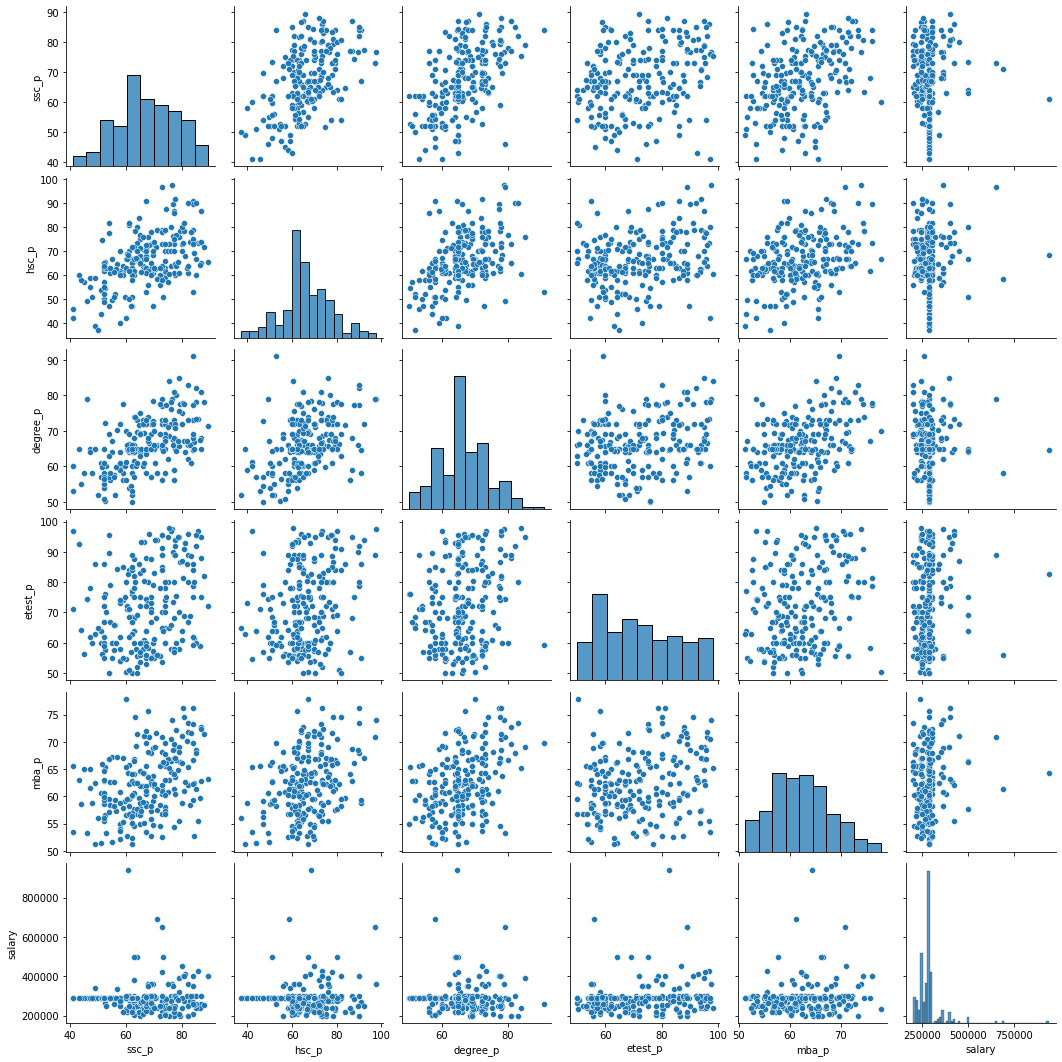

In [37]:
import seaborn as sns
sns.pairplot(df)

In [38]:
###could see linear pattern ssc_p and hsc_p & ssc_p and degree_p & etc in above picture

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor ##import the function variance_inflation_factor

def cal_vif(X):
    
    ##calculate VIF
    vif=pd.DataFrame()  ## Creating new dataframe
    vif["variables"]=X.columns ## Converting column names as column values
    
    ## for i in range(X.shape[1])--> shape[1]-gives the number of columns and loop executes until number of columns
    ## for each column index and row values , VIF is calulated using variance_inflation_factor(X.values,i)
    
    vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
    return vif




In [40]:
from UnivariateFile import UnivariateAnalysis as ua
Quan,Qual=ua.univariate(df)

In [48]:
cal_vif(dataset[Quan])

,variables,VIF
0,ssc_p,67.02670
1,hsc_p,56.13149
2,degree_p,112.75527
3,etest_p,33.69639
4,mba_p,108.58546
5,salary,15.16770


In [ ]:
## All variables are highly correlated which means Multicollinearity exists

In [ ]:
#####  Ways to remove Multicollinearity
""""
1. Remove Highly Correlated Features using correlation matrix df.corr():
If two variables are highly correlated and have similar information then keep one remove the other feature.

2. Using VIF:
If, VIF > 5 → high correlation or VIF > 10 → severe multicollinearity then remove features with highest VIF.

##vif["VIF"]=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]

3.Using Principal Component Analysis:
PCA transforms correlated variables into uncorrelated components. This works well only if many correlated features 
exist and interpretability is less important.

##from sklearn.decomposition import PCA

4. Using Ridge Regression:
To reduce coefficient instability caused by multicollinearity by adding L2 penalty to the loss function.
It keeps all the features and reduces coefficient variance and does NOT make coefficients exactly zero.

5. Using Lasso Regression:
This can automatically remove less important correlated variables. Some coefficients become exactly zero.

6. Feature Engineering / Combining Variables:
Combine related variables into one.

###Example:
ssc_p
hsc_p

Create:
school_total_marks = ssc_p + hsc_p

7. Collect More Data:
Sometimes multicollinearity becomes less severe with larger datasets.So this way is useful only when sample size 
is too small and many similar features exist

8. Domain Knowledge Based Selection:
Choosing the most meaningful feature based on business understanding.

###Example:
keep mba_p
remove degree_p
because both represent similar information.